In [1]:
import XRootD
import copy # copiar variables
import os   # gestionar rutas
import uproot   # Leer archivos ROOT sin usar ROOT directamente.
import awkward as ak  # Manejar arreglos tipo "jagged" (listas de listas, una por evento).
import vector   # vectores de Lorentz
vector.register_awkward()
import matplotlib.pyplot as plt # Para hacer gráficos.
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import tqdm # barras de progreso
import re
import random
import subprocess
import atlasopenmagic as atom # Paquete de datos abiertos ATLAS
from tabulate import tabulate # Para hacer tablas
from matplotlib.ticker import FixedLocator, FixedFormatter

## Estoy usando los datos de: 

## https://opendata.cern.ch/record/80036

In [2]:
# Ruta al archivo ROOT
ArchivosIones = [
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi//DAOD_HION14.41691891._000001.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000002.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000037.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000127.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000128.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000129.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000130.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000131.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000132.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000133.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000134.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000135.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000136.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000038.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000137.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000138.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000139.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000140.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000141.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000142.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000143.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000144.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000145.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000146.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000039.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000040.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000041.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000042.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000043.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000044.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000045.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000046.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000003.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000047.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000048.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000049.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000050.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000051.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000052.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000053.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000054.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000055.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000056.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000005.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000057.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000058.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000059.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000060.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000061.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000062.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000063.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000064.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000065.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000066.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000006.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000067.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000068.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000069.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000070.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000071.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000072.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000073.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000074.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000075.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000076.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000007.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000077.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000078.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000079.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000080.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000081.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000082.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000083.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000084.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000085.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000086.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000008.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000087.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000088.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000089.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000090.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000091.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000092.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000093.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000094.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000095.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000096.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000009.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000097.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000098.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000099.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000100.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000101.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000102.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000103.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000104.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000105.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000106.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000010.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000107.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000108.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000109.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000110.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000111.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000112.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000113.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000114.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000115.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000116.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000036.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000117.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000118.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000119.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000120.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000121.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000122.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000123.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000124.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000125.pool.root.1",
    "root://eospublic.cern.ch//eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691891._000126.pool.root.1"
]

Usar el archivo número

In [3]:
print('Objetos TTree dentro del archivo ROOT:')
for ii in uproot.open(ArchivosIones[0]).keys():
    print('-',ii)

Objetos TTree dentro del archivo ROOT:
- ##Params;2
- ##Params;1
- ##Shapes;2
- ##Shapes;1
- ##Links;2
- ##Links;1
- CollectionTree;1
- POOLContainer;1
- POOLContainerForm;1
- POOLCollectionTree;1
- MetaData;1
- MetaDataHdr;1
- MetaDataHdrForm;1


# En una variable llamada ¨Tree" asignaré toda la información del árbol CollectionTree, el cuál tiene información de las ramas que voy a utilizar.

In [ ]:
# =========================
# 0) Ajustes XRootD (mejoran estabilidad)
# =========================
os.environ["XRD_REQUESTTIMEOUT"]   = "300"
os.environ["XRD_TIMEOUT"]          = "300"
os.environ["XRD_CONNECTIONRETRY"]  = "20"
os.environ["XRD_CONNECTIONWINDOW"] = "120"

TREE_NAME = "CollectionTree"

# =========================
# 1) Config
# =========================
N_OK  = 20     # cuántos archivos QUIERES realmente leídos (OK iterate)
N_TRY = 200    # cuántos intentas como máximo (sube si tu red falla mucho)
archivos_try = ArchivosIones[:min(N_TRY, len(ArchivosIones))]

# =========================
# 2) SOLO ramas necesarias para m_mumu + muonType + quality
# =========================


BR_QOVERP     = "InDetTrackParticlesAuxDyn.qOverP"
BR_THETA    = "InDetTrackParticlesAuxDyn.theta"
BR_PHI    = "InDetTrackParticlesAuxDyn.phi"
BR_CENTRALITYMIN = "EventInfoAuxDyn.CentralityMin"
BR_CENTRALITYMAX   = "EventInfoAuxDyn.CentralityMax"     

ramas = [BR_QOVERP, BR_THETA, BR_PHI, BR_CENTRALITYMIN, BR_CENTRALITYMAX]

# =========================
# 3) Función para xrdfs stat
# =========================
def split_root_url(u: str):
    # root://host//path...
    assert u.startswith("root://")
    rest = u[len("root://"):]
    if "//" not in rest:
        raise ValueError(f"URL no tiene //path: {u}")
    host, path = rest.split("//", 1)
    return host, "/" + path

def xrdfs_stat_ok(u: str, timeout_s=15) -> bool:
    host, path = split_root_url(u)
    r = subprocess.run(
        ["xrdfs", f"root://{host}", "stat", path],
        capture_output=True, text=True, timeout=timeout_s
    )
    return (r.returncode == 0)

# =========================
# 4) Leer archivos hasta juntar N_OK leídos de verdad
# =========================
chunks = {br: [] for br in ramas}
read_ok = []
read_fail = []
stat_fail = []

print(f"Buscando {N_OK} archivos realmente leídos (OK iterate) probando hasta {len(archivos_try)}...")

for u in archivos_try:
    if len(read_ok) >= N_OK:
        break

    # 4.1 pre-chequeo rápido
    try:
        if not xrdfs_stat_ok(u, timeout_s=15):
            stat_fail.append(u)
            print("STAT FAIL:", u.split("_")[-1])
            continue
    except subprocess.TimeoutExpired:
        stat_fail.append(u)
        print("STAT TO  :", u.split("_")[-1])
        continue
    except Exception as e:
        stat_fail.append(u)
        print("STAT ERR :", u.split("_")[-1], "->", str(e).splitlines()[0])
        continue

    # 4.2 lectura real
    try:
        for arrays in uproot.iterate(
            {u: TREE_NAME},
            ramas,
            step_size="2 MB",     # más pequeño = más estable en remoto
            library="ak",
            how=dict,
            allow_missing=True,
        ):
            for br in ramas:
                if br in arrays:
                    chunks[br].append(arrays[br])

        read_ok.append(u)
        print(f"OK iterate: {u.split('_')[-1]}  | total OK = {len(read_ok)}/{N_OK}")

    except Exception as e:
        read_fail.append((u, str(e).splitlines()[0]))
        print("FAIL iterate:", u.split("_")[-1], "->", str(e).splitlines()[0])

print("\n=========================")
print("Resumen")
print("=========================")
print("Objetivo N_OK:", N_OK)
print("OK iterate (leídos):", len(read_ok))
print("FAIL iterate:", len(read_fail))
print("FAIL/TO stat:", len(stat_fail))

if len(read_ok) == 0:
    raise RuntimeError("No se pudo leer ningún archivo (0 OK iterate). Prueba otro endpoint o aumenta timeouts.")

# =========================
# 5) Concatenar (solo lo leído)
# =========================
def concat_or_fail(lst, name):
    if len(lst) == 0:
        raise RuntimeError(f"No se juntó ningún chunk para {name}.")
    return ak.concatenate(lst, axis=0)

QoverP     = concat_or_fail(chunks[BR_QOVERP], BR_QOVERP)
Theta    = concat_or_fail(chunks[BR_THETA], BR_THETA)
Phi    = concat_or_fail(chunks[BR_PHI], BR_PHI)
CentralityMin = concat_or_fail(chunks[BR_CENTRALITYMIN], BR_CENTRALITYMIN)
CentralityMax   = concat_or_fail(chunks[BR_CENTRALITYMAX], BR_CENTRALITYMAX)   


# =========================
# 6) Conteos
# =========================
n_evt = len(CentralityMin)
n_partículas  = int(ak.sum(ak.num(Theta, axis=1)))

print("\n✅ Listo.")
print("Archivos OK iterate usados:", len(read_ok))
print("Eventos leídos:", n_evt)
print("Partículas totales:", n_partículas)

print("\nArchivos OK iterate (lista):")
for f in read_ok:
    print(" -", f)

Buscando 20 archivos realmente leídos (OK iterate) probando hasta 120...
OK iterate: 000001.pool.root.1  | total OK = 1/20


# =========================================================
# CONTEO ROBUSTO DE EVENTOS POR ARCHIVO (CollectionTree)
# =========================================================

# =========================
# 0) Ajustes XRootD (mejoran estabilidad)
# =========================
os.environ["XRD_REQUESTTIMEOUT"]   = "300"
os.environ["XRD_TIMEOUT"]          = "300"
os.environ["XRD_CONNECTIONRETRY"]  = "20"
os.environ["XRD_CONNECTIONWINDOW"] = "120"

TREE_NAME = "CollectionTree"

# =========================
# 1) Config
# =========================
archivos_in = ArchivosIones

N_OK  = 40      # cuántos archivos QUIERES realmente leídos
N_TRY = 200     # cuántos intentas como máximo
STEP  = "50 MB" # chunk size (remoto: 2–50 MB suele ser estable)

archivos_try = archivos_in[:min(N_TRY, len(archivos_in))]

# =========================
# 2) Ramas necesarias (las TUYAS)
# =========================
ramas = [
    "InDetTrackParticlesAuxDyn.qOverP",
    "InDetTrackParticlesAuxDyn.theta",
    "InDetTrackParticlesAuxDyn.phi",
    "EventInfoAuxDyn.FCalEtA",
    "EventInfoAuxDyn.FCalEtA_Q2x",
    "EventInfoAuxDyn.FCalEtA_Q2y",
    "EventInfoAuxDyn.CentralityMin",
    "EventInfoAuxDyn.CentralityMax",
]

# =========================
# 3) Funciones para xrdfs stat
# =========================
def split_root_url(u: str):
    # root://host//path...
    if not u.startswith("root://"):
        raise ValueError(f"URL no es root:// ... -> {u}")
    rest = u[len("root://"):]
    if "//" not in rest:
        raise ValueError(f"URL no tiene //path: {u}")
    host, path = rest.split("//", 1)
    return host, "/" + path

def xrdfs_stat_ok(u: str, timeout_s=15) -> bool:
    host, path = split_root_url(u)
    r = subprocess.run(
        ["xrdfs", f"root://{host}", "stat", path],
        capture_output=True, text=True, timeout=timeout_s
    )
    return (r.returncode == 0)

# =========================
# 4) Leer archivos hasta juntar N_OK leídos de verdad
# =========================
nombres = [os.path.basename(a) for a in archivos_try]
eventos_por_archivo = {name: 0 for name in nombres}
Nevt_total = 0

read_ok   = []
read_fail = []
stat_fail = []

print(f"Buscando {N_OK} archivos realmente leídos (OK iterate) probando hasta {len(archivos_try)}...")

for u in archivos_try:
    if len(read_ok) >= N_OK:
        break

    name = os.path.basename(u)

    # 4.1) pre-chequeo rápido
    try:
        if not xrdfs_stat_ok(u, timeout_s=15):
            stat_fail.append(u)
            print("STAT FAIL:", name)
            continue
    except subprocess.TimeoutExpired:
        stat_fail.append(u)
        print("STAT TO  :", name)
        continue
    except Exception as e:
        stat_fail.append(u)
        print("STAT ERR :", name, "->", str(e).splitlines()[0])
        continue

    # 4.2) lectura real (solo para contar eventos)
    # Nota: NO necesitas zippear para contar, solo tomar len(EventInfoAuxDyn.FCalEtA) por chunk.
    ok_this = False
    try:
        for arrays in uproot.iterate(
            {u: TREE_NAME},
            ramas,
            step_size=STEP,
            library="ak",
            how=dict,
            allow_missing=True,
        ):
            # si por algún motivo no vino esta rama, intenta con otra de EventInfo (todas tienen len = Nevt)
            if "EventInfoAuxDyn.FCalEtA" in arrays:
                n_evt_chunk = len(arrays["EventInfoAuxDyn.FCalEtA"])
            elif "EventInfoAuxDyn.CentralityMin" in arrays:
                n_evt_chunk = len(arrays["EventInfoAuxDyn.CentralityMin"])
            else:
                # si ni siquiera vino EventInfo, no podemos contar eventos en este chunk
                continue

            eventos_por_archivo[name] = eventos_por_archivo.get(name, 0) + n_evt_chunk
            Nevt_total += n_evt_chunk
            ok_this = True

        if ok_this:
            read_ok.append(u)
            print(f"OK iterate: {name}  | total OK = {len(read_ok)}/{N_OK}")
        else:
            # se pudo abrir pero no se pudo contar (ramas faltantes en todos los chunks)
            read_fail.append((u, "No llegaron ramas de EventInfo para contar eventos"))
            print("FAIL iterate:", name, "-> No llegaron ramas de EventInfo")

    except Exception as e:
        read_fail.append((u, str(e).splitlines()[0]))
        print("FAIL iterate:", name, "->", str(e).splitlines()[0])

print("\n=========================")
print("Resumen")
print("=========================")
print("Objetivo N_OK:", N_OK)
print("OK iterate (leídos):", len(read_ok))
print("FAIL iterate:", len(read_fail))
print("FAIL/TO stat:", len(stat_fail))

if len(read_ok) == 0:
    raise RuntimeError("No se pudo leer ningún archivo (0 OK iterate). Prueba otro endpoint o aumenta timeouts.")

print("\nResumen de eventos por archivo (solo los probados):")
for name, n in eventos_por_archivo.items():
    print(f"{name} : {n} eventos")

print("\nEventos totales (sumando archivos OK):", Nevt_total)

print("\nArchivos OK iterate (lista):")
for f in read_ok:
    print(" -", os.path.basename(f))

# Creando dos diccionarios, uno que tenga información de las partículas y otro que tenga información de los eventos (colisiones)

In [ ]:
particulas = ak.zip(
    {
        "qOverP": tree["InDetTrackParticlesAuxDyn.qOverP"].array(library="ak"),
        "theta": tree["InDetTrackParticlesAuxDyn.theta"].array(library="ak"),
        "phi": tree["InDetTrackParticlesAuxDyn.phi"].array(library="ak"),
    }
)

eventos = ak.zip(
    {
        "FCalEtA": tree["EventInfoAuxDyn.FCalEtA"].array(),
        "FCalEtA_Q2x": tree["EventInfoAuxDyn.FCalEtA_Q2x"].array(library="ak"),
        "FCalEtA_Q2y": tree["EventInfoAuxDyn.FCalEtA_Q2y"].array(library="ak"),
        "CentralityMin": tree["EventInfoAuxDyn.CentralityMin"].array(library="ak"),
        "CentralityMax": tree["EventInfoAuxDyn.CentralityMax"].array(library="ak"),
    }
)

## Un ejemplo de cómo llamar las ramas que tengo en el diccionario "partículas" y "eventos".

In [ ]:
particulas.theta, particulas.phi, eventos.CentralityMin

# Numero total de eventos (Colisiones de iones de plomo - plomo)

In [ ]:
print("Número de eventos en 'particulas':", len(particulas))
print("Número de eventos en 'eventos':", len(eventos))

Se puede observar que en ambos diccionarios hay la misma cantidad de eventos (tiene sentido).

# Centralidad promedio por evento

In [ ]:
centrality_prom_event = 0.5 * (eventos.CentralityMin + eventos.CentralityMax)

# Cantidad de eventos segun la centralidad de la colisión

In [ ]:
# --- ENTRADA: centrality_prom_event ---
# Debe contener UN valor de centralidad por evento (0–100).
# Si hubiera NaN/inf, los quitamos:
cent = ak.to_numpy(centrality_prom_event)
cent = cent[np.isfinite(cent)]

# --- Definir clases de centralidad (bins de 10%) ---
bins   = np.arange(0, 110, 10)                       # 0,10,...,100
labels = [f"{i}-{i+10}%" for i in range(0, 100, 10)] # "0-10%", ..., "90-100%"

# --- Contar eventos por clase ---
cent_classes = pd.cut(cent, bins=bins, labels=labels, right=False)
Nevt = cent_classes.value_counts().sort_index()      # Serie indexada por clase

# --- Armar tabla con totales y porcentajes ---
total_evt = int(Nevt.sum())
tabla_evt = pd.DataFrame({
    "Clase de centralidad": Nevt.index,
    "N_evt": Nevt.values,
})
tabla_evt["Porcentaje"] = 100 * tabla_evt["N_evt"] / total_evt
tabla_evt.loc[len(tabla_evt)] = ["Total de eventos", total_evt, 100.0]

# --- Mostrar/usar ---
print(tabla_evt.to_string(index=False))

# (Opcional) acceso directo al número de eventos por clase para R_AA:
Nevt_dict = dict(zip(Nevt.index, Nevt.values))
# Ejemplo: Nevt_dict["0-10%"] te da N_evt de 0–10%


## Cantidad de partículas en una determinada clase de centralidad

In [ ]:
# --- máscaras por centralidad ---
mask_evt_0_5  = (centrality_prom_event >= 0) & (centrality_prom_event < 5)
mask_evt_5_10 = (centrality_prom_event >= 5) & (centrality_prom_event < 10)

# --- seleccionar partículas de esos eventos ---
particulas_0_5  = particulas[mask_evt_0_5]
particulas_5_10 = particulas[mask_evt_5_10]

# --- contar partículas (tracks) en cada rango ---
N_part_0_5  = ak.sum(ak.num(particulas_0_5.qOverP))
N_part_5_10 = ak.sum(ak.num(particulas_5_10.qOverP))

print("Número de partículas en 0–5% :", N_part_0_5)
print("Número de partículas en 5–10%:", N_part_5_10)

# Momento transverso

In [ ]:
# Filtrar datos válidos
validas = (particulas.qOverP != 0) & np.isfinite(particulas.qOverP) & np.isfinite(particulas.theta)
particulas = particulas[validas]

# Calcular momento total y momento transverso (en MeV)
p = 1 / np.abs(particulas.qOverP) # Momento total
pt = p * np.sin(particulas.theta) # Momento transverso, me los da por evento (Tipo matriz)
pt_flattened = ak.flatten(pt) # Momento transverso, me los da por partícula (Vector)

# Seudorapidez

In [ ]:
# 1) Calcular pseudorrapidez η a partir de θ

# η = -ln(tan(θ/2))
eta = -np.log(np.tan(particulas.theta / 2.0))  

# Aplanar si quieres graficar
eta_flat = ak.to_numpy(ak.flatten(eta))

In [ ]:
eta, eta_flat

In [ ]:
print("Total de partículas en todos los eventos de eta:", ak.sum(ak.num(eta)))
print("Total de valores en eta_flat:", len(eta_flat) )

# Histograma de Seudorapidez

In [ ]:
# --- Histograma N vs η ---
plt.figure(figsize=(8,6))
plt.hist(
    eta_flat,
    bins=100,          # cantidad total de bins que tendrá el gráfico
    histtype="step",   # estilo línea
    color="royalblue"
)

plt.xlabel(r"$\eta$")
plt.ylabel("Número de partículas (N)")
plt.title("Distribución de pseudorapidez de partículas cargadas")
plt.grid(True)
plt.show()

# Histograma global de pseudorapidez (dN/dη)

In [ ]:
# --- Definición de bins para η ---
bins = np.linspace(-3, 3, 20)  # rango típico de pseudorapidez en ATLAS (algo que se comprobó en gráfico anterior)
bin_width = bins[1] - bins[0]   # ancho de bin

# --- Número de eventos ---
N_evt = len(eventos)   # total de eventos en tu dataset

# --- Histograma bruto (N) ---
counts, _ = np.histogram(ak.to_numpy(eta_flat), bins=bins)

# --- dN/dη (dividido por ancho de bin) ---
dN_deta = counts / bin_width

# --- (1/N_evt) dN/dη ---
dN_deta_norm = dN_deta / N_evt

# --- Graficar ---
plt.figure(figsize=(10,6))

plt.step(bins[:-1], counts, where="mid", label=r"$N(\eta)$ (conteo bruto)", color="royalblue")
plt.step(bins[:-1], dN_deta, where="mid", label=r"$\frac{dN}{d\eta}$", color="darkorange")
plt.step(bins[:-1], dN_deta_norm, where="mid", label=r"$\frac{1}{N_{\rm evt}}\frac{dN}{d\eta}$", color="seagreen")

plt.xlabel(r"Pseudorapidez $\eta$", fontsize=14)
plt.ylabel("Número de partículas / Densidad", fontsize=14)
plt.title("Comparación: $N$, $dN/d\eta$, y $(1/N_{evt})dN/d\eta$", fontsize=15)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Histograma de η por clase de centralidad

In [ ]:
# ==============================
# Distribución de η por clase de centralidad
# ==============================

# Repetir centralidad por partícula (igual que antes)
centrality_repeated = ak.unflatten(
    np.repeat(centrality_prom_event, ak.num(eta)),
    ak.num(eta)
)

# DataFrame con η y centralidad
df_eta = pd.DataFrame({
    "eta": ak.to_numpy(ak.flatten(eta)),
    "Centrality": ak.to_numpy(ak.flatten(centrality_repeated))
})

# Definir clases de centralidad
centrality_bins = [(0,10),(10,20),(20,30),(30,40),(40,50),(50,60)]
labels = [f"{lo}-{hi}%" for lo, hi in centrality_bins]

plt.figure(figsize=(10,7))

# Graficar cada clase
for (lo, hi), label in zip(centrality_bins, labels):
    mask = (df_eta["Centrality"] >= lo) & (df_eta["Centrality"] < hi)
    plt.hist(df_eta.loc[mask,"eta"], bins=100, range=(-5,5), 
             histtype="step", linewidth=1.2, label=label)

plt.xlabel(r"Pseudorapidez $\eta$", fontsize=14)
plt.ylabel(r"$\frac{dN}{d\eta}$", fontsize=14)
plt.title("Distribución de pseudorapidez por centralidad", fontsize=16)
plt.legend(title="Centralidad")
plt.grid(True)
plt.tight_layout()
plt.show()

# Espectro de partículas por evento
## Promedio de partículas cargadas por evento por unidad de seudorapidez y momento transverso

# $$
\frac{1}{N_{evt}}\frac{d^{2}N_{PbPb}}{d\eta\, dp_{T}}
= \frac{1}{N_{evt}}\,E\,\frac{d^{3}N_{PbPb}}{d^{3}p}
$$

# Obs: Ya hice la demostración de la ecuación anterior.

In [ ]:
# =========================
# 0) Definir clase de centralidad y factor del rendimiento invariante
# =========================
CENT_LO, CENT_HI = 0, 5
FACTOR_INV = 10

# =========================
# 1) Filtrar eventos por centralidad
# =========================
mask_evt       = (centrality_prom_event >= CENT_LO) & (centrality_prom_event < CENT_HI)
eventos_sel    = eventos[mask_evt]
particulas_sel = particulas[mask_evt]
Nevt           = int(len(centrality_prom_event[mask_evt]))

# =========================
# 2) pT (GeV) y pseudorrapidez η por partícula; corte |η|<1
# =========================
qOverP_sel = particulas_sel.qOverP
theta_sel  = particulas_sel.theta
p_mev  = 1.0 / np.abs(qOverP_sel)
pt_mev = p_mev * np.sin(theta_sel)
pt_gev = pt_mev / 1000.0
eta_sel = -np.log(np.tan(theta_sel / 2.0))
mask_eta    = np.abs(eta_sel) < 1.0
pt_Filtrado = ak.to_numpy(ak.flatten(pt_gev[mask_eta]))

# =========================
# 3) Bins de pT EXACTOS hasta 400 GeV
# =========================
pt_intervalos = np.array([
    0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 3.2, 4.0, 
    4.8, 5.6, 6.4, 7.2, 9.6, 12.0, 14.4, 19.2, 24.0, 28.8, 35.2, 41.6, 
    48.0, 60.8, 73.6, 86.4, 103.6, 120.8, 140.0, 165.0, 250.0, 400.0], 
    dtype=float)

pt_low  = pt_intervalos[:-1]
pt_high = pt_intervalos[1:]
Delta_pt      = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)

N_ij, _ = np.histogram(pt_Filtrado, bins=pt_intervalos)

# =========================
# 4) (1/Nevt) d^2N/(dη dpT) con |η|<1 → Δη = 2
# =========================
Delta_eta  = 2.0
Espectro   = N_ij / (Nevt * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij) / (Nevt * Delta_eta * Delta_pt)

# =========================
# 5) Rendimiento invariante
# =========================
InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr   = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# =========================
# 6) Gráfica SOLO de rendimiento invariante
# =========================
mask_bins = N_ij > 0
x    = pt_centro_Bin[mask_bins]
y2   = InvYield[mask_bins]
e2   = InvErr[mask_bins]
xerr = np.vstack([x - pt_low[mask_bins], pt_high[mask_bins] - x])

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.8))

ax.errorbar(x, y2, xerr=xerr, yerr=e2, fmt="o", linestyle="none", capsize=0, color="crimson")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(pt_intervalos[0], pt_intervalos[-1])
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(rf"${FACTOR_INV}\times\frac{{1}}{{N_{{\rm evt}}}}E\frac{{d^3N}}{{dp^3}}$  [$\mathrm{{GeV}}^{{-2}}$]")
ax.set_title(r"Rendimiento invariante")
ax.grid(True, which="both", ls="--", alpha=0.35)

ticks = pt_intervalos
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

# =========================
# 7) Tabla SOLO de rendimiento invariante (10 decimales en columnas 5 y 6)
# =========================
mask = N_ij > 0
tabla_invar = pd.DataFrame({
    "pT_low [GeV]":  pt_low[mask],
    "pT_high [GeV]": pt_high[mask],
    "pT_center [GeV]": pt_centro_Bin[mask],
    f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]": InvYield[mask],
    "stat_err [GeV^-2]": InvErr[mask],
    "counts": N_ij[mask],
})
col_y = f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]"
tabla_invar[col_y] = tabla_invar[col_y].map(lambda v: float(f"{v:.10f}"))
tabla_invar["stat_err [GeV^-2]"] = tabla_invar["stat_err [GeV^-2]"].map(lambda v: float(f"{v:.10f}"))
print("\nTabla: Rendimiento invariante")
display(tabla_invar.style.format({col_y: "{:.10f}", "stat_err [GeV^-2]": "{:.10f}"}))

### En el siguiente enlace, se muestra el resultado (gráfico) de lo que debería obtener:

### https://www.hepdata.net/record/ins1496050?version=2&table=Table%208

In [ ]:
# =========================
# (DESPUÉS de tu tabla_invar) Comparación ATLAS (calculado) vs HEPData + GRÁFICO SUPERPUESTO (con ruta HEP_DIR)
# (asume que YA existen: tabla_invar, FACTOR_INV, CENT_LO, CENT_HI, (opcional) pt_intervalos
# =========================

HEP_DIR = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"

hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_1.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_2.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_3.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_4.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_5.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_6.csv",
}

clave_cent = (CENT_LO, CENT_HI)
if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(
        f"No tengo mapeado el archivo HEPData para centralidad {CENT_LO}-{CENT_HI}%. "
        f"Opciones válidas: {sorted(list(hep_archivos_por_centralidad.keys()))}"
    )

archivo_hep = os.path.join(HEP_DIR, hep_archivos_por_centralidad[clave_cent])
if not os.path.exists(archivo_hep):
    raise FileNotFoundError(
        f"No existe: {archivo_hep}\n"
        f"Tip: revisa nombres con: !ls -lh {HEP_DIR}"
    )

# =========================================================
# 1) LEER HEPData
# =========================================================
df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")

pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
y_hep_raw   = df_hep.iloc[:, 3].astype(float).to_numpy()

# detectar si la columna trae "10 * ..." y corregir al FACTOR_INV de tu tabla
factor_hep = 1.0
try:
    nombre_col_valor = str(df_hep.columns[3])
    m = re.match(r"^\s*([0-9]+(?:\.[0-9]+)?)\s*\*", nombre_col_valor)
    if m:
        factor_hep = float(m.group(1))
except Exception:
    factor_hep = 1.0

y_hep = y_hep_raw * (FACTOR_INV / factor_hep)

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_value": y_hep,
})

# =========================================================
# 2) TABLA ATLAS (DESDE TU tabla_invar)
# =========================================================
col_y = f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]"
tabla_atlas = (
    tabla_invar[["pT_low [GeV]", "pT_high [GeV]", "pT_center [GeV]", col_y]]
    .copy()
    .rename(columns={col_y: "ATLAS_value"})
)

# =========================================================
# 3) MERGE ROBUSTO POR BORDES DE BIN
# =========================================================
for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_value"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

tabla_comp["Porcentaje de error [%]"] = (
    np.abs(tabla_comp["ATLAS_value"] - tabla_comp["HEP_value"]) / tabla_comp["HEP_value"]
) * 100.0

tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]": "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "ATLAS_value": "Valor medido ATLAS",
    "HEP_value": "Valor medido HEP",
})

print(f"\nTabla: Comparación ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}%  (archivo: {archivo_hep})")
display(tabla_comp.style.format({
    "PTlow [GeV]": "{:.1f}",
    "PThigh [GeV]": "{:.1f}",
    "PT [GeV]": "{:.2f}",
    "Valor medido ATLAS": "{:.15f}",
    "Valor medido HEP": "{:.15f}",
    "Porcentaje de error [%]": "{:.6f}",
}))

# =========================================================
# 4) GRÁFICO SUPERPUESTO: ATLAS vs HEPData (log-log)
# =========================================================
x      = tabla_comp["PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_comp["Valor medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_comp["Valor medido HEP"].to_numpy(dtype=float)

ptlow  = tabla_comp["PTlow [GeV]"].to_numpy(dtype=float)
pthigh = tabla_comp["PThigh [GeV]"].to_numpy(dtype=float)
xerr   = np.vstack([x - ptlow, pthigh - x])

m = np.isfinite(x) & np.isfinite(y_at) & np.isfinite(y_hep2) & (x > 0) & (y_at > 0) & (y_hep2 > 0)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(x[m], y_at[m],   xerr=xerr[:, m], fmt="o", linestyle="none", capsize=0, label="ATLAS (calculado)")
ax.errorbar(x[m], y_hep2[m], xerr=xerr[:, m], fmt="s", linestyle="none", capsize=0, label="HEPData")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(rf"${FACTOR_INV}\times\frac{{1}}{{N_{{\rm evt}}}}E\frac{{d^3N}}{{dp^3}}$  [$\mathrm{{GeV}}^{{-2}}$]")
ax.set_title(rf"Rendimiento invariante: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%)")
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

# ticks del eje x
if "pt_intervalos" in globals():
    ticks = pt_intervalos
else:
    ticks = np.sort(np.unique(np.concatenate([ptlow, pthigh])))

ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

ax.set_xlim(float(np.min(ticks)), float(np.max(ticks)))
plt.tight_layout()
plt.show()

### Observación: Obtuve una muy buena aproximación de los valores numéricos.

# Recortando el intervalo

In [ ]:
# =========================
# (DESPUÉS de tu tabla_invar) Comparación ATLAS (calculado) vs HEPData + GRÁFICO SUPERPUESTO (RECORTE pT<=19.2) + ruta HEP_DIR
# (asume que YA existen: tabla_invar, FACTOR_INV, CENT_LO, CENT_HI, (opcional) pt_intervalos
# =========================
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

PT_MAX = 19.2  # <-- recorte máximo en pT (GeV)

HEP_DIR = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_1.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_2.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_3.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_4.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_5.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_6.csv",
}

clave_cent = (CENT_LO, CENT_HI)
if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(f"No tengo mapeado el archivo HEPData para centralidad {CENT_LO}-{CENT_HI}%. Opciones válidas: {sorted(list(hep_archivos_por_centralidad.keys()))}")

archivo_hep = os.path.join(HEP_DIR, hep_archivos_por_centralidad[clave_cent])
if not os.path.exists(archivo_hep):
    raise FileNotFoundError(f"No existe: {archivo_hep}\nTip: revisa nombres con: !ls -lh {HEP_DIR}")

df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")

pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
y_hep_raw   = df_hep.iloc[:, 3].astype(float).to_numpy()

factor_hep = 1.0
try:
    nombre_col_valor = str(df_hep.columns[3])
    m = re.match(r"^\s*([0-9]+(?:\.[0-9]+)?)\s*\*", nombre_col_valor)
    if m: factor_hep = float(m.group(1))
except Exception:
    factor_hep = 1.0

y_hep = y_hep_raw * (FACTOR_INV / factor_hep)

tabla_hep = pd.DataFrame({"pT_low [GeV]": pt_low_hep, "pT_high [GeV]": pt_high_hep, "pT_center [GeV]": pt_hep, "HEP_value": y_hep})

col_y = f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]"
tabla_atlas = tabla_invar[["pT_low [GeV]", "pT_high [GeV]", "pT_center [GeV]", col_y]].copy().rename(columns={col_y: "ATLAS_value"})

for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(tabla_atlas, tabla_hep[["_low_key", "_high_key", "HEP_value"]], on=["_low_key", "_high_key"], how="inner")

# ===> RECORTE pT: conservar bins con borde superior <= 19.2 GeV
tabla_comp = tabla_comp[tabla_comp["pT_high [GeV]"] <= PT_MAX].copy()

tabla_comp["Porcentaje de error [%]"] = (np.abs(tabla_comp["ATLAS_value"] - tabla_comp["HEP_value"]) / tabla_comp["HEP_value"]) * 100.0
tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]": "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "ATLAS_value": "Valor medido ATLAS",
    "HEP_value": "Valor medido HEP",
})

print(f"\nTabla: Comparación ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}% (archivo: {archivo_hep})  con recorte pT<= {PT_MAX} GeV")
display(tabla_comp.style.format({
    "PTlow [GeV]": "{:.1f}",
    "PThigh [GeV]": "{:.1f}",
    "PT [GeV]": "{:.2f}",
    "Valor medido ATLAS": "{:.15f}",
    "Valor medido HEP": "{:.15f}",
    "Porcentaje de error [%]": "{:.6f}",
}))

x      = tabla_comp["PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_comp["Valor medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_comp["Valor medido HEP"].to_numpy(dtype=float)
ptlow  = tabla_comp["PTlow [GeV]"].to_numpy(dtype=float)
pthigh = tabla_comp["PThigh [GeV]"].to_numpy(dtype=float)
xerr   = np.vstack([x - ptlow, pthigh - x])

m = np.isfinite(x) & np.isfinite(y_at) & np.isfinite(y_hep2) & (x > 0) & (y_at > 0) & (y_hep2 > 0)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(x[m], y_at[m],   xerr=xerr[:, m], fmt="o", linestyle="none", capsize=0, label="ATLAS (calculado)")
ax.errorbar(x[m], y_hep2[m], xerr=xerr[:, m], fmt="s", linestyle="none", capsize=0, label="HEPData")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(float(np.min(ptlow)) if len(ptlow) else 0.7, PT_MAX)
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(rf"${FACTOR_INV}\times\frac{{1}}{{N_{{\rm evt}}}}E\frac{{d^3N}}{{dp^3}}$  [$\mathrm{{GeV}}^{{-2}}$]")
ax.set_title(rf"Rendimiento invariante: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%), $p_T\leq{PT_MAX}$ GeV")
ax.grid(True, which="both", ls="--", alpha=0.35); ax.legend()

if "pt_intervalos" in globals():
    ticks = pt_intervalos[pt_intervalos <= PT_MAX]
else:
    ticks = np.unique(np.concatenate([ptlow, pthigh])); ticks = ticks[ticks <= PT_MAX]
ticks = np.sort(ticks)

ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

# Espectro diferencial de la sección eficaz inelástica en colisiones protón-protón

### Tomé los datos de HEP (Tabla 7)

In [ ]:
# =========================
# 0) Ruta correcta del CSV (AJUSTA SOLO ESTA PARTE)
# =========================
HEP_DIR = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"
archivo = os.path.join(HEP_DIR, "HEPData-Table_7-Espectro-pp.csv")

print("Directorio actual:", os.getcwd())
print("Buscando archivo:", archivo)
if not os.path.exists(archivo):
    raise FileNotFoundError(f"No existe el archivo:\n{archivo}\nRevisa el nombre exacto con: !ls -lh {HEP_DIR}")

# =========================
# 1) Leer CSV ignorando el header con "#"
# =========================
df = pd.read_csv(archivo, comment="#", sep=",", engine="python")

# =========================
# 2) Tomar columnas (LOW/HIGH) para pT y el espectro
# =========================
pt_low  = df.iloc[:, 1].astype(float).to_numpy()   # PT [GeV] LOW
pt_high = df.iloc[:, 2].astype(float).to_numpy()   # PT [GeV] HIGH

pt   = 0.5 * (pt_low + pt_high)                    # centro del bin
xerr = np.vstack([pt - pt_low, pt_high - pt])      # barras horizontales

y = df.iloc[:, 3].astype(float).to_numpy()         # (1/N) E d^3N/dp^3 [GeV^-2]

# =========================
# 2.5) Tabla
# =========================
tabla_pp = pd.DataFrame({
    "pT_low [GeV]": pt_low,
    "pT_high [GeV]": pt_high,
    "pT_center [GeV]": pt,
    "(1/N) E d^3N/dp^3 [GeV^-2]": y,
})
print("\nTabla: Espectro pp (HEPData Table 7)")
display(tabla_pp)

# =========================
# 3) Gráfico
# =========================
plt.figure(figsize=(7, 5))
plt.errorbar(pt, y, xerr=xerr, fmt="o", linestyle="none", capsize=0)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel(r"$(1/N)\,E\,d^3N/dp^3\ \,[\mathrm{GeV}^{-2}]$")
plt.title("Espectro pp (HEPData Table 7)")
plt.grid(True, which="both", ls="--", alpha=0.4)

ticks = np.unique(np.concatenate([pt_low, pt_high]))
ticks = np.sort(ticks)

ax = plt.gca()
ax.set_xlim(ticks.min(), ticks.max())
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

# Factor de modificación nuclear/Función de soplamiento nuclear promedio (TAA)

### La información la puedo encontrar en: 

#### La información la puedo encontrar en: 

- Punto uno ATLAS-CONF-2017-012: Mean values of
https://cds.cern.ch/record/2244824/files/ATLAS-CONF-2017-012.pdf  
CERN Document Server

- Punto dos CMS Charged-particle nuclear modification factors at 5.02 TeV — contiene RAA y la incertidumbre de TAA que se usa en el análisis:
 📄 https://arxiv.org/pdf/1611.01664.pdf

- Punto tres ATLAS y ALICE measurements de espectros y RAA en Pb-Pb 5.02 TeV — muestran resultados de RAA,implica el uso de TAA del Glauber model:
 📄 https://cds.cern.ch/record/2842355/files/ANA-HION-2018-17-PAPER.pdf

- Punto cuatro https://doi.org/10.1016/j.physletb.2018.10.076
  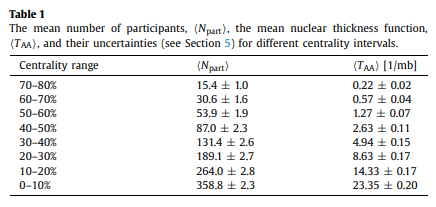

# FACTOR DE MODIFICACIÓN NUCLEAR (RAA)

In [ ]:
# =========================
# R_AA usando (PbPb desde tus arrays eventos/particulas) + (pp desde HEPData CSV con ruta)
# =========================

# 0) Centralidad y factores
CENT_LO, CENT_HI = 5, 10
FACTOR_INV = 10
SIGMA_PP_INEL = 70.0  # [mb]
TAA_por_centralidad = {(0,5):26.23,(5,10):20.47,(10,30):11.7,(30,50):3.82,(50,70):0.934,(70,90):0.152}
clave_cent = (int(CENT_LO), int(CENT_HI))
if clave_cent not in TAA_por_centralidad:
    raise ValueError(f"No tengo TAA mapeado para {CENT_LO}-{CENT_HI}%. Opciones: {sorted(TAA_por_centralidad.keys())}")
TAA = float(TAA_por_centralidad[clave_cent])
print(f"TAA asignado automáticamente para {CENT_LO}-{CENT_HI}%: {TAA} mb^-1")

# 1) Filtrar eventos por centralidad (asume que ya existen: centrality_prom_event, eventos, particulas)
mask_evt       = (centrality_prom_event >= CENT_LO) & (centrality_prom_event < CENT_HI)
eventos_sel    = eventos[mask_evt]
particulas_sel = particulas[mask_evt]
Nevt           = int(len(centrality_prom_event[mask_evt]))
if Nevt == 0:
    raise ValueError("Nevt=0: no hay eventos en esa centralidad.")

# 2) pT (GeV) y η; corte |η|<1
qOverP_sel = particulas_sel.qOverP
theta_sel  = particulas_sel.theta
p_mev  = 1.0 / np.abs(qOverP_sel)
pt_mev = p_mev * np.sin(theta_sel)
pt_gev = pt_mev / 1000.0
eta_sel = -np.log(np.tan(theta_sel / 2.0))
mask_eta    = np.abs(eta_sel) < 1.0
pt_Filtrado = ak.to_numpy(ak.flatten(pt_gev[mask_eta]))

# 3) Bins pT
pt_intervalos = np.array([0.7,0.8,0.9,1.0,1.1,1.2,1.4,1.6,1.8,2.0,2.2,2.4,3.2,4.0,4.8,5.6,6.4,7.2,9.6,12.0,14.4,19.2,24.0,28.8,35.2,41.6,48.0,60.8,73.6,86.4,103.6,120.8,140.0,165.0,250.0,400.0], dtype=float)
pt_low  = pt_intervalos[:-1]
pt_high = pt_intervalos[1:]
Delta_pt      = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)
N_ij, _ = np.histogram(pt_Filtrado, bins=pt_intervalos)

# 4) (1/Nevt) d^2N/(dη dpT), Δη=2
Delta_eta  = 2.0
Espectro   = N_ij / (Nevt * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij) / (Nevt * Delta_eta * Delta_pt)

# 5) Rendimiento invariante PbPb (con FACTOR_INV)
InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr   = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# 6) Leer pp (HEPData) desde ruta y escalar con el MISMO FACTOR_INV (para que cancele en R_AA)
HEP_DIR = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"
archivo_pp = os.path.join(HEP_DIR, "HEPData-Table_7-Espectro-pp.csv")
if not os.path.exists(archivo_pp):
    raise FileNotFoundError(f"No existe el archivo:\n{archivo_pp}\nRevisa el nombre exacto con: !ls -lh {HEP_DIR}")
df = pd.read_csv(archivo_pp, comment="#", sep=",", engine="python")
pt_low_pp  = df.iloc[:, 1].astype(float).to_numpy()
pt_high_pp = df.iloc[:, 2].astype(float).to_numpy()
pt_pp      = 0.5 * (pt_low_pp + pt_high_pp)
y_pp_raw   = df.iloc[:, 3].astype(float).to_numpy()
yerr_pp_raw = None
if df.shape[1] >= 5:
    try: yerr_pp_raw = df.iloc[:, 4].astype(float).to_numpy()
    except Exception: yerr_pp_raw = None
y_pp = FACTOR_INV * y_pp_raw
yerr_pp = (FACTOR_INV * yerr_pp_raw) if yerr_pp_raw is not None else None

# 7) Interpolar pp a los centros de bin de PbPb (en log-log) + (opcional) error relativo
mask_ok = (pt_pp > 0) & np.isfinite(pt_pp) & (y_pp > 0) & np.isfinite(y_pp)
pt_ok, y_ok = pt_pp[mask_ok], y_pp[mask_ok]
logpt, logy = np.log(pt_ok), np.log(y_ok)
pt_eval = pt_centro_Bin
mask_range = (pt_eval >= pt_ok.min()) & (pt_eval <= pt_ok.max()) & np.isfinite(pt_eval) & (pt_eval > 0)
inv_pp_interp = np.full_like(pt_eval, np.nan, dtype=float)
inv_pp_interp[mask_range] = np.exp(np.interp(np.log(pt_eval[mask_range]), logpt, logy))
if yerr_pp is not None:
    rel = np.where(y_ok > 0, (yerr_pp[mask_ok] / y_ok), np.nan)
    rel_interp = np.full_like(pt_eval, np.nan, dtype=float)
    rel_interp[mask_range] = np.interp(np.log(pt_eval[mask_range]), logpt, rel)
    inv_pp_interp_err = rel_interp * inv_pp_interp
else:
    inv_pp_interp_err = np.zeros_like(pt_eval, dtype=float)

# 8) Calcular R_AA y su error (propagación simple)
denom     = (TAA * SIGMA_PP_INEL) * inv_pp_interp
denom_err = (TAA * SIGMA_PP_INEL) * inv_pp_interp_err
RAA = InvYield / denom
RAA_err = np.abs(RAA) * np.sqrt((InvErr / np.where(InvYield != 0, InvYield, np.nan))*2 + (denom_err / np.where(denom != 0, denom, np.nan))*2)

mask = (N_ij > 0) & np.isfinite(RAA) & np.isfinite(RAA_err) & np.isfinite(denom) & (denom > 0) & np.isfinite(InvYield) & (InvYield > 0)

# 9) Gráfico R_AA
x    = pt_centro_Bin[mask]
xerr = np.vstack([x - pt_low[mask], pt_high[mask] - x])
fig, ax = plt.subplots(1, 1, figsize=(7.8, 5.2))
ax.errorbar(x, RAA[mask], xerr=xerr, yerr=RAA_err[mask], fmt="o", linestyle="none", capsize=0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(pt_intervalos[0], pt_intervalos[-1])
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(r"$R_{AA}(p_T)$")
ax.set_title(rf"$R_{{AA}}$ Pb--Pb {CENT_LO}--{CENT_HI}\%, $|\eta|<1$; $T_{{AA}}={TAA}$ mb$^{{-1}}$, $\sigma_{{pp}}^{{inel}}={SIGMA_PP_INEL}$ mb")
ax.grid(True, which="both", ls="--", alpha=0.35)
ticks = pt_intervalos
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()
plt.tight_layout(); plt.show()

# 10) Tabla R_AA
tabla_raa = pd.DataFrame({"PT_low [GeV]": pt_low[mask], "PThigh [GeV]": pt_high[mask], "PT_center [GeV]": pt_centro_Bin[mask], "RAA": RAA[mask], "RAA_stat_err": RAA_err[mask]})
print(f"\nNevt (PbPb {CENT_LO}-{CENT_HI}%) = {Nevt:,} | bins válidos = {int(np.sum(mask))}/{len(pt_centro_Bin)}")
print("\nTabla: RAA (solo bins válidos)")
display(tabla_raa.style.format({"PT_low [GeV]":"{:.1f}","PThigh [GeV]":"{:.1f}","PT_center [GeV]":"{:.2f}","RAA":"{:.6f}","RAA_stat_err":"{:.6f}"}))

# Comparando resultados

In [ ]:
# =========================
# COMPARACIÓN R_AA: (ATLAS calculado desde eventos/particulas) vs HEPData + GRÁFICO SUPERPUESTO
# (usa tu cálculo RAA/RAA_err y lo compara con los CSV de HEPData Table_8..13)
# + agrega columna de CUENTAS (ATLAS) y fila final: TOTAL CUENTAS
# + mantiene PT mostrado con 2 decimales (sin romper por fila "Total cuentas")
# =========================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

# -------------------------
# 0) Centralidad y factores
# -------------------------
CENT_LO, CENT_HI = 0, 5
FACTOR_INV = 10
SIGMA_PP_INEL = 70.0  # [mb]

TAA_por_centralidad = {
    (0.0, 5.0):  26.23,
    (5.0, 10.0): 20.47,
    (10.0, 30.0): 11.7,
    (30.0, 50.0): 3.82,
    (50.0, 70.0): 0.934,
    (70.0, 100.0): 0.152,
}

clave_cent = (float(CENT_LO), float(CENT_HI))
if clave_cent not in TAA_por_centralidad:
    raise ValueError(
        f"No tengo TAA mapeado para {CENT_LO}-{CENT_HI}%. "
        f"Opciones: {sorted(TAA_por_centralidad.keys())}"
    )
TAA = float(TAA_por_centralidad[clave_cent])
print(f"TAA asignado automáticamente para {CENT_LO}-{CENT_HI}%: {TAA} mb^-1")

# -------------------------
# 1) PbPb: filtrar eventos
# (asume que ya existen: centrality_prom_event, eventos, particulas, y ak)
# -------------------------
mask_evt       = (centrality_prom_event >= CENT_LO) & (centrality_prom_event < CENT_HI)
eventos_sel    = eventos[mask_evt]
particulas_sel = particulas[mask_evt]
Nevt           = int(len(centrality_prom_event[mask_evt]))
if Nevt == 0:
    raise ValueError("Nevt=0: no hay eventos en esa centralidad.")

# -------------------------
# 2) pT (GeV) y eta, |eta|<1
# -------------------------
qOverP_sel = particulas_sel.qOverP
theta_sel  = particulas_sel.theta
p_mev  = 1.0 / np.abs(qOverP_sel)
pt_mev = p_mev * np.sin(theta_sel)
pt_gev = pt_mev / 1000.0
eta_sel = -np.log(np.tan(theta_sel / 2.0))
mask_eta    = np.abs(eta_sel) < 1.0
pt_Filtrado = ak.to_numpy(ak.flatten(pt_gev[mask_eta]))

# -------------------------
# 3) Bins pT
# -------------------------
pt_intervalos = np.array(
    [0.7,0.8,0.9,1.0,1.1,1.2,1.4,1.6,1.8,2.0,2.2,2.4,3.2,4.0,4.8,5.6,6.4,7.2,9.6,12.0,14.4,19.2,
     24.0,28.8,35.2,41.6,48.0,60.8,73.6,86.4,103.6,120.8,140.0,165.0,250.0,400.0],
    dtype=float
)
pt_low  = pt_intervalos[:-1]
pt_high = pt_intervalos[1:]
Delta_pt      = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)
N_ij, _ = np.histogram(pt_Filtrado, bins=pt_intervalos)

# -------------------------
# 4) Espectro (1/Nevt) d^2N/(deta dpT), Δη=2
# -------------------------
Delta_eta  = 2.0
Espectro   = N_ij / (Nevt * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij) / (Nevt * Delta_eta * Delta_pt)

# -------------------------
# 5) Rendimiento invariante PbPb
# -------------------------
InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr   = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# -------------------------
# 6) pp desde HEPData Table_7 (ruta)
# -------------------------
HEP_DIR_PP = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"
archivo_pp = os.path.join(HEP_DIR_PP, "HEPData-Table_7-Espectro-pp.csv")
if not os.path.exists(archivo_pp):
    raise FileNotFoundError(
        f"No existe el archivo:\n{archivo_pp}\n"
        f"Revisa el nombre exacto con: !ls -lh {HEP_DIR_PP}"
    )

dfpp = pd.read_csv(archivo_pp, comment="#", sep=",", engine="python")
pt_pp      = 0.5 * (dfpp.iloc[:, 1].astype(float).to_numpy() + dfpp.iloc[:, 2].astype(float).to_numpy())
y_pp_raw   = dfpp.iloc[:, 3].astype(float).to_numpy()

yerr_pp_raw = None
if dfpp.shape[1] >= 5:
    try:
        yerr_pp_raw = dfpp.iloc[:, 4].astype(float).to_numpy()
    except Exception:
        yerr_pp_raw = None

# escalar pp con el MISMO FACTOR_INV (se cancela en R_AA, pero mantiene consistencia numérica)
y_pp = FACTOR_INV * y_pp_raw
yerr_pp = (FACTOR_INV * yerr_pp_raw) if yerr_pp_raw is not None else None

# interpolación log-log de pp en los centros de bin PbPb
mask_ok = (pt_pp > 0) & np.isfinite(pt_pp) & (y_pp > 0) & np.isfinite(y_pp)
pt_ok, y_ok = pt_pp[mask_ok], y_pp[mask_ok]
logpt, logy = np.log(pt_ok), np.log(y_ok)

pt_eval = pt_centro_Bin
mask_range = (pt_eval >= pt_ok.min()) & (pt_eval <= pt_ok.max()) & np.isfinite(pt_eval) & (pt_eval > 0)

inv_pp_interp = np.full_like(pt_eval, np.nan, dtype=float)
inv_pp_interp[mask_range] = np.exp(np.interp(np.log(pt_eval[mask_range]), logpt, logy))

if yerr_pp is not None:
    rel = np.where(y_ok > 0, (yerr_pp[mask_ok] / y_ok), np.nan)
    rel_interp = np.full_like(pt_eval, np.nan, dtype=float)
    rel_interp[mask_range] = np.interp(np.log(pt_eval[mask_range]), logpt, rel)
    inv_pp_interp_err = rel_interp * inv_pp_interp
else:
    inv_pp_interp_err = np.zeros_like(pt_eval, dtype=float)

# -------------------------
# 7) R_AA calculado + error
# -------------------------
denom     = (TAA * SIGMA_PP_INEL) * inv_pp_interp
denom_err = (TAA * SIGMA_PP_INEL) * inv_pp_interp_err

RAA = InvYield / denom
RAA_err = np.abs(RAA) * np.sqrt(
    (InvErr / np.where(InvYield != 0, InvYield, np.nan))**2 +
    (denom_err / np.where(denom != 0, denom, np.nan))**2
)

mask = (N_ij > 0) & np.isfinite(RAA) & np.isfinite(RAA_err) & np.isfinite(denom) & (denom > 0) & (InvYield > 0)

# construir arrays tipo "ATLAS"
pt_c = pt_centro_Bin
xerr_atlas = np.vstack([pt_c - pt_low, pt_high - pt_c])

# -------------------------
# 8) Leer R_AA de HEPData (Table_8..13) con ruta
# -------------------------
HEP_DIR_RAA = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_8.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_9.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_10.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_11.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_12.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_13.csv",
}

clave_cent_int = (int(CENT_LO), int(CENT_HI))
# (si tu centralidad es 70-100, usa el CSV de 70-90 como venías haciendo)
if clave_cent_int == (70, 100):
    clave_para_hep = (70, 90)
else:
    clave_para_hep = clave_cent_int

if clave_para_hep not in hep_archivos_por_centralidad:
    raise ValueError(
        f"No hay archivo HEPData RAA para centralidad {CENT_LO}-{CENT_HI}%. "
        f"Opciones: {sorted(hep_archivos_por_centralidad.keys())}"
    )

archivo_hep = os.path.join(HEP_DIR_RAA, hep_archivos_por_centralidad[clave_para_hep])
if not os.path.exists(archivo_hep):
    raise FileNotFoundError(f"No existe: {archivo_hep}\nTip: revisa nombres con: !ls -lh {HEP_DIR_RAA}")

df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")
pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
raa_hep     = df_hep.iloc[:, 3].astype(float).to_numpy()

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_RAA": raa_hep,
})

# -------------------------
# 9) Tabla ATLAS (desde tu cálculo) + CUENTAS
# -------------------------
tabla_atlas = pd.DataFrame({
    "pT_low [GeV]":    pt_low[mask],
    "pT_high [GeV]":   pt_high[mask],
    "pT_center [GeV]": pt_c[mask],
    "ATLAS_RAA":       RAA[mask],
    "counts":          N_ij[mask],   # <-- CUENTAS (ATLAS) por bin (tus N_ij)
})

# merge robusto por bordes
for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_RAA"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

tabla_comp["Porcentaje de error [%]"] = (np.abs(tabla_comp["ATLAS_RAA"] - tabla_comp["HEP_RAA"]) / tabla_comp["HEP_RAA"]) * 100.0

tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]":    "PTlow [GeV]",
    "pT_high [GeV]":   "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "ATLAS_RAA":       "RAA medido ATLAS",
    "HEP_RAA":         "RAA medido HEP",
    "counts":          "Cuentas (ATLAS)",
})

# Reordenar columnas: CUENTAS justo antes de % error
orden_cols = [
    "PTlow [GeV]",
    "PThigh [GeV]",
    "PT [GeV]",
    "RAA medido ATLAS",
    "RAA medido HEP",
    "Cuentas (ATLAS)",
    "Porcentaje de error [%]",
]
tabla_comp = tabla_comp[orden_cols]

# -------------------------
# 9.1) Fila final: Total cuentas
# -------------------------
total_cuentas = int(np.nansum(tabla_comp["Cuentas (ATLAS)"].to_numpy(dtype=float)))

fila_total = {
    "PTlow [GeV]": np.nan,
    "PThigh [GeV]": np.nan,
    "PT [GeV]": "Total cuentas",
    "RAA medido ATLAS": np.nan,
    "RAA medido HEP": np.nan,
    "Cuentas (ATLAS)": total_cuentas,
    "Porcentaje de error [%]": np.nan,
}
tabla_comp = pd.concat([tabla_comp, pd.DataFrame([fila_total])], ignore_index=True)

# -------------------------
# 9.2) Mostrar tabla (PT a 2 decimales, sin error por fila final)
# -------------------------
print(
    f"\nTabla: Comparación R_AA ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}% "
    f"(archivo: {os.path.basename(archivo_hep)})"
)

def fmt_num(dec):
    def _f(x):
        if x is None:
            return ""
        if isinstance(x, str):
            return x
        try:
            if np.isnan(x):
                return ""
        except Exception:
            pass
        return f"{float(x):.{dec}f}"
    return _f

def fmt_int(x):
    if x is None:
        return ""
    if isinstance(x, str):
        return x
    try:
        if np.isnan(x):
            return ""
    except Exception:
        pass
    return f"{int(round(float(x))):d}"

display(
    tabla_comp.style.format({
        "PTlow [GeV]": fmt_num(1),
        "PThigh [GeV]": fmt_num(1),
        "PT [GeV]": fmt_num(2),               # <-- 2 decimales
        "RAA medido ATLAS": fmt_num(6),
        "RAA medido HEP": fmt_num(6),
        "Cuentas (ATLAS)": fmt_int,           # <-- evita "Unknown format code 'd' for float"
        "Porcentaje de error [%]": fmt_num(3),
    })
)

# -------------------------
# 10) Gráfico superpuesto ATLAS vs HEPData (mismos bins)
# -------------------------
# quitar fila final para plot
tabla_plot = tabla_comp.iloc[:-1].copy()

x      = tabla_plot["PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_plot["RAA medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_plot["RAA medido HEP"].to_numpy(dtype=float)

ptlow_plot  = tabla_plot["PTlow [GeV]"].to_numpy(dtype=float)
pthigh_plot = tabla_plot["PThigh [GeV]"].to_numpy(dtype=float)
xerr_plot   = np.vstack([x - ptlow_plot, pthigh_plot - x])

mplot = np.isfinite(x) & np.isfinite(y_at) & np.isfinite(y_hep2) & (x > 0) & (y_at > 0) & (y_hep2 > 0)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(x[mplot], y_at[mplot],   xerr=xerr_plot[:, mplot], fmt="o", linestyle="none", capsize=0, label="ATLAS (calculado)")
ax.errorbar(x[mplot], y_hep2[mplot], xerr=xerr_plot[:, mplot], fmt="s", linestyle="none", capsize=0, label="HEPData")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(r"$R_{AA}(p_T)$")
ax.set_title(rf"Comparación $R_{{AA}}$: ATLAS vs HEPData ({CENT_LO}–{CENT_HI}\%)")
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

# ticks
ticks = pt_intervalos if "pt_intervalos" in globals() else np.unique(np.concatenate([ptlow_plot, pthigh_plot]))
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()
ax.set_xlim(float(np.min(ticks)), float(np.max(ticks)))

plt.tight_layout()
plt.show()

# Acortando el intervalo de PT

In [ ]:
# =========================
# COMPARACIÓN R_AA: (ATLAS calculado desde eventos/particulas) vs HEPData + GRÁFICO SUPERPUESTO
# con RECORTE pT <= 19.2 GeV (tabla + gráfico)
# =========================

import os


PT_MAX = 19.2  # corte máximo en pT (GeV)

# -------------------------
# 0) Centralidad y factores
# -------------------------
CENT_LO, CENT_HI = 0, 5
FACTOR_INV = 10
SIGMA_PP_INEL = 70.0  # [mb]

TAA_por_centralidad = {
    (0, 5): 26.23,
    (5, 10): 20.47,
    (10, 30): 11.7,
    (30, 50): 3.82,
    (50, 70): 0.934,
    (70, 90): 0.152,
}

clave_cent = (int(CENT_LO), int(CENT_HI))
if clave_cent not in TAA_por_centralidad:
    raise ValueError(f"No tengo TAA mapeado para {CENT_LO}-{CENT_HI}%. Opciones: {sorted(TAA_por_centralidad.keys())}")
TAA = float(TAA_por_centralidad[clave_cent])
print(f"TAA asignado automáticamente para {CENT_LO}-{CENT_HI}%: {TAA} mb^-1")

# -------------------------
# 1) PbPb: filtrar eventos
# (asume que ya existen: centrality_prom_event, eventos, particulas, y ak)
# -------------------------
mask_evt       = (centrality_prom_event >= CENT_LO) & (centrality_prom_event < CENT_HI)
eventos_sel    = eventos[mask_evt]
particulas_sel = particulas[mask_evt]
Nevt           = int(len(centrality_prom_event[mask_evt]))
if Nevt == 0:
    raise ValueError("Nevt=0: no hay eventos en esa centralidad.")

# -------------------------
# 2) pT (GeV) y eta, |eta|<1
# -------------------------
qOverP_sel = particulas_sel.qOverP
theta_sel  = particulas_sel.theta
p_mev  = 1.0 / np.abs(qOverP_sel)
pt_mev = p_mev * np.sin(theta_sel)
pt_gev = pt_mev / 1000.0
eta_sel = -np.log(np.tan(theta_sel / 2.0))
mask_eta    = np.abs(eta_sel) < 1.0
pt_Filtrado = ak.to_numpy(ak.flatten(pt_gev[mask_eta]))

# -------------------------
# 3) Bins pT (hasta 400), pero luego recortamos a PT_MAX
# -------------------------
pt_intervalos = np.array([
    0.7,0.8,0.9,1.0,1.1,1.2,1.4,1.6,1.8,2.0,2.2,2.4,3.2,4.0,
    4.8,5.6,6.4,7.2,9.6,12.0,14.4,19.2,24.0,28.8,35.2,41.6,
    48.0,60.8,73.6,86.4,103.6,120.8,140.0,165.0,250.0,400.0
], dtype=float)

pt_low  = pt_intervalos[:-1]
pt_high = pt_intervalos[1:]
Delta_pt      = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)
N_ij, _ = np.histogram(pt_Filtrado, bins=pt_intervalos)

# -------------------------
# 4) Espectro (1/Nevt) d^2N/(deta dpT), Δη=2
# -------------------------
Delta_eta  = 2.0
Espectro   = N_ij / (Nevt * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij) / (Nevt * Delta_eta * Delta_pt)

# -------------------------
# 5) Rendimiento invariante PbPb
# -------------------------
InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr   = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# -------------------------
# 6) pp desde HEPData Table_7 (ruta)
# -------------------------
HEP_DIR_PP = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"
archivo_pp = os.path.join(HEP_DIR_PP, "HEPData-Table_7-Espectro-pp.csv")
if not os.path.exists(archivo_pp):
    raise FileNotFoundError(f"No existe el archivo:\n{archivo_pp}\nRevisa el nombre exacto con: !ls -lh {HEP_DIR_PP}")

dfpp = pd.read_csv(archivo_pp, comment="#", sep=",", engine="python")
pt_pp      = 0.5 * (dfpp.iloc[:, 1].astype(float).to_numpy() + dfpp.iloc[:, 2].astype(float).to_numpy())
y_pp_raw   = dfpp.iloc[:, 3].astype(float).to_numpy()

yerr_pp_raw = None
if dfpp.shape[1] >= 5:
    try:
        yerr_pp_raw = dfpp.iloc[:, 4].astype(float).to_numpy()
    except Exception:
        yerr_pp_raw = None

# escalar pp con el MISMO FACTOR_INV (se cancela en R_AA)
y_pp = FACTOR_INV * y_pp_raw
yerr_pp = (FACTOR_INV * yerr_pp_raw) if yerr_pp_raw is not None else None

# interpolación log-log de pp en los centros de bin PbPb
mask_ok = (pt_pp > 0) & np.isfinite(pt_pp) & (y_pp > 0) & np.isfinite(y_pp)
pt_ok, y_ok = pt_pp[mask_ok], y_pp[mask_ok]
logpt, logy = np.log(pt_ok), np.log(y_ok)

pt_eval = pt_centro_Bin
mask_range = (pt_eval >= pt_ok.min()) & (pt_eval <= pt_ok.max()) & np.isfinite(pt_eval) & (pt_eval > 0)

inv_pp_interp = np.full_like(pt_eval, np.nan, dtype=float)
inv_pp_interp[mask_range] = np.exp(np.interp(np.log(pt_eval[mask_range]), logpt, logy))

if yerr_pp is not None:
    rel = np.where(y_ok > 0, (yerr_pp[mask_ok] / y_ok), np.nan)
    rel_interp = np.full_like(pt_eval, np.nan, dtype=float)
    rel_interp[mask_range] = np.interp(np.log(pt_eval[mask_range]), logpt, rel)
    inv_pp_interp_err = rel_interp * inv_pp_interp
else:
    inv_pp_interp_err = np.zeros_like(pt_eval, dtype=float)

# -------------------------
# 7) R_AA calculado + error
# -------------------------
denom     = (TAA * SIGMA_PP_INEL) * inv_pp_interp
denom_err = (TAA * SIGMA_PP_INEL) * inv_pp_interp_err

RAA = InvYield / denom
RAA_err = np.abs(RAA) * np.sqrt(
    (InvErr / np.where(InvYield != 0, InvYield, np.nan))**2 +
    (denom_err / np.where(denom != 0, denom, np.nan))**2
)

mask_valid = (N_ij > 0) & np.isfinite(RAA) & np.isfinite(RAA_err) & np.isfinite(denom) & (denom > 0) & (InvYield > 0)

# -------------------------
# 8) Leer R_AA de HEPData (Table_8..13) + recorte pT<=PT_MAX
# -------------------------
HEP_DIR_RAA = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_8.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_9.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_10.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_11.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_12.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_13.csv",
}
if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(f"No hay archivo HEPData RAA para centralidad {CENT_LO}-{CENT_HI}%. Opciones: {sorted(hep_archivos_por_centralidad.keys())}")

archivo_hep = os.path.join(HEP_DIR_RAA, hep_archivos_por_centralidad[clave_cent])
if not os.path.exists(archivo_hep):
    raise FileNotFoundError(f"No existe: {archivo_hep}\nTip: revisa nombres con: !ls -lh {HEP_DIR_RAA}")

df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")
pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
raa_hep     = df_hep.iloc[:, 3].astype(float).to_numpy()

mask_hep_pt = np.isfinite(pt_low_hep) & np.isfinite(pt_high_hep) & np.isfinite(raa_hep) & (pt_high_hep <= PT_MAX)
pt_low_hep, pt_high_hep, pt_hep, raa_hep = pt_low_hep[mask_hep_pt], pt_high_hep[mask_hep_pt], pt_hep[mask_hep_pt], raa_hep[mask_hep_pt]

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_RAA": raa_hep,
})

# -------------------------
# 9) Tabla ATLAS (desde tu cálculo) + recorte pT<=PT_MAX
# -------------------------
mask_atlas_pt = (pt_high <= PT_MAX)
tabla_atlas = pd.DataFrame({
    "pT_low [GeV]":   pt_low[mask_valid & mask_atlas_pt],
    "pT_high [GeV]":  pt_high[mask_valid & mask_atlas_pt],
    "pT_center [GeV]": pt_centro_Bin[mask_valid & mask_atlas_pt],
    "ATLAS_RAA":      RAA[mask_valid & mask_atlas_pt],
})

# merge robusto por bordes
for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_RAA"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

tabla_comp["Porcentaje de error [%]"] = (np.abs(tabla_comp["ATLAS_RAA"] - tabla_comp["HEP_RAA"]) / tabla_comp["HEP_RAA"]) * 100.0

tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]":  "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]":"PT [GeV]",
    "ATLAS_RAA":     "RAA medido ATLAS",
    "HEP_RAA":       "RAA medido HEP",
})

print(f"\nTabla: Comparación R_AA ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}% (archivo: {os.path.basename(archivo_hep)})  |  corte: pT <= {PT_MAX} GeV")
display(tabla_comp.style.format({
    "PTlow [GeV]": "{:.1f}",
    "PThigh [GeV]": "{:.1f}",
    "PT [GeV]": "{:.2f}",
    "RAA medido ATLAS": "{:.6f}",
    "RAA medido HEP": "{:.6f}",
    "Porcentaje de error [%]": "{:.3f}",
}))

# -------------------------
# 10) Gráfico superpuesto ATLAS vs HEPData (<= PT_MAX)
# -------------------------
x = tabla_comp["PT [GeV]"].to_numpy(dtype=float)
y_at = tabla_comp["RAA medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_comp["RAA medido HEP"].to_numpy(dtype=float)

ptlow_plot = tabla_comp["PTlow [GeV]"].to_numpy(dtype=float)
pthigh_plot = tabla_comp["PThigh [GeV]"].to_numpy(dtype=float)
xerr_plot = np.vstack([x - ptlow_plot, pthigh_plot - x])

mplot = (
    np.isfinite(x) & np.isfinite(y_at) & np.isfinite(y_hep2) &
    (x > 0) & (y_at > 0) & (y_hep2 > 0)
)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(
    x[mplot], y_at[mplot],
    xerr=xerr_plot[:, mplot],
    fmt="o", linestyle="none", capsize=0,
    label="ATLAS (calculado)"
)
ax.errorbar(
    x[mplot], y_hep2[mplot],
    xerr=xerr_plot[:, mplot],
    fmt="s", linestyle="none", capsize=0,
    label="HEPData"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(float(np.min(ptlow_plot)) if len(ptlow_plot) else 0.7, PT_MAX)

ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(r"$R_{AA}(p_T)$")
ax.set_title(
    rf"Comparación $R_{{AA}}$: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%)  |  $p_T \leq {PT_MAX}$ GeV"
)
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

# ticks X hasta PT_MAX (como ya lo tenías)
ticks = pt_intervalos[pt_intervalos <= PT_MAX]
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

# ======= SOLO AÑADIDO: valores visibles en eje Y (sin tocar tu log) =======
# Elegidos para R_AA típico: 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0
y_ticks = np.array([0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0], dtype=float)
ax.yaxis.set_major_locator(FixedLocator(y_ticks))
ax.yaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in y_ticks]))
# opcional: quita ticks menores de Y si te estorban visualmente
ax.tick_params(axis="y", labelsize=10)
# =======================================================

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# COMPARACIÓN R_AA: (ATLAS calculado desde eventos/particulas) vs HEPData + GRÁFICO SUPERPUESTO
# con RECORTE pT <= 19.2 GeV (tabla + gráfico)
# =========================

import os

PT_MAX = 19.2  # corte máximo en pT (GeV)

# -------------------------
# 0) Centralidad y factores
# -------------------------
CENT_LO, CENT_HI = 70, 100
FACTOR_INV = 10
SIGMA_PP_INEL = 70.0  # [mb]

TAA_por_centralidad = {
    (0, 5): 26.23,
    (5, 10): 20.47,
    (10, 30): 11.7,
    (30, 50): 3.82,
    (50, 70): 0.934,
    (70, 100): 0.152,
}

clave_cent = (int(CENT_LO), int(CENT_HI))
if clave_cent not in TAA_por_centralidad:
    raise ValueError(f"No tengo TAA mapeado para {CENT_LO}-{CENT_HI}%. Opciones: {sorted(TAA_por_centralidad.keys())}")
TAA = float(TAA_por_centralidad[clave_cent])
print(f"TAA asignado automáticamente para {CENT_LO}-{CENT_HI}%: {TAA} mb^-1")

# -------------------------
# 1) PbPb: filtrar eventos
# (asume que ya existen: centrality_prom_event, eventos, particulas)
# -------------------------
mask_evt       = (centrality_prom_event >= CENT_LO) & (centrality_prom_event < CENT_HI)
eventos_sel    = eventos[mask_evt]
particulas_sel = particulas[mask_evt]
Nevt           = int(len(centrality_prom_event[mask_evt]))
if Nevt == 0:
    raise ValueError("Nevt=0: no hay eventos en esa centralidad.")

# -------------------------
# 2) pT (GeV) y eta, |eta|<1
# -------------------------
qOverP_sel = particulas_sel.qOverP
theta_sel  = particulas_sel.theta
p_mev  = 1.0 / np.abs(qOverP_sel)
pt_mev = p_mev * np.sin(theta_sel)
pt_gev = pt_mev / 1000.0
eta_sel = -np.log(np.tan(theta_sel / 2.0))
mask_eta    = np.abs(eta_sel) < 1.0
pt_Filtrado = ak.to_numpy(ak.flatten(pt_gev[mask_eta]))

# -------------------------
# 3) Bins pT (hasta 400), pero luego recortamos a PT_MAX
# -------------------------
pt_intervalos = np.array([
    0.7,0.8,0.9,1.0,1.1,1.2,1.4,1.6,1.8,2.0,2.2,2.4,3.2,4.0,
    4.8,5.6,6.4,7.2,9.6,12.0,14.4,19.2,24.0,28.8,35.2,41.6,
    48.0,60.8,73.6,86.4,103.6,120.8,140.0,165.0,250.0,400.0
], dtype=float)

pt_low  = pt_intervalos[:-1]
pt_high = pt_intervalos[1:]
Delta_pt      = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)
N_ij, _ = np.histogram(pt_Filtrado, bins=pt_intervalos)

# -------------------------
# 4) Espectro (1/Nevt) d^2N/(deta dpT), Δη=2
# -------------------------
Delta_eta  = 2.0
Espectro   = N_ij / (Nevt * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij) / (Nevt * Delta_eta * Delta_pt)

# -------------------------
# 5) Rendimiento invariante PbPb
# -------------------------
InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr   = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# -------------------------
# 6) pp desde HEPData Table_7 (ruta)
# -------------------------
HEP_DIR_PP = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"
archivo_pp = os.path.join(HEP_DIR_PP, "HEPData-Table_7-Espectro-pp.csv")
if not os.path.exists(archivo_pp):
    raise FileNotFoundError(f"No existe el archivo:\n{archivo_pp}\nRevisa el nombre exacto con: !ls -lh {HEP_DIR_PP}")

dfpp = pd.read_csv(archivo_pp, comment="#", sep=",", engine="python")
pt_pp      = 0.5 * (dfpp.iloc[:, 1].astype(float).to_numpy() + dfpp.iloc[:, 2].astype(float).to_numpy())
y_pp_raw   = dfpp.iloc[:, 3].astype(float).to_numpy()

yerr_pp_raw = None
if dfpp.shape[1] >= 5:
    try:
        yerr_pp_raw = dfpp.iloc[:, 4].astype(float).to_numpy()
    except Exception:
        yerr_pp_raw = None

# escalar pp con el MISMO FACTOR_INV (se cancela en R_AA)
y_pp = FACTOR_INV * y_pp_raw
yerr_pp = (FACTOR_INV * yerr_pp_raw) if yerr_pp_raw is not None else None

# interpolación log-log de pp en los centros de bin PbPb
mask_ok = (pt_pp > 0) & np.isfinite(pt_pp) & (y_pp > 0) & np.isfinite(y_pp)
pt_ok, y_ok = pt_pp[mask_ok], y_pp[mask_ok]
logpt, logy = np.log(pt_ok), np.log(y_ok)

pt_eval = pt_centro_Bin
mask_range = (pt_eval >= pt_ok.min()) & (pt_eval <= pt_ok.max()) & np.isfinite(pt_eval) & (pt_eval > 0)

inv_pp_interp = np.full_like(pt_eval, np.nan, dtype=float)
inv_pp_interp[mask_range] = np.exp(np.interp(np.log(pt_eval[mask_range]), logpt, logy))

if yerr_pp is not None:
    rel = np.where(y_ok > 0, (yerr_pp[mask_ok] / y_ok), np.nan)
    rel_interp = np.full_like(pt_eval, np.nan, dtype=float)
    rel_interp[mask_range] = np.interp(np.log(pt_eval[mask_range]), logpt, rel)
    inv_pp_interp_err = rel_interp * inv_pp_interp
else:
    inv_pp_interp_err = np.zeros_like(pt_eval, dtype=float)

# -------------------------
# 7) R_AA calculado + error
# -------------------------
denom     = (TAA * SIGMA_PP_INEL) * inv_pp_interp
denom_err = (TAA * SIGMA_PP_INEL) * inv_pp_interp_err

RAA = InvYield / denom
RAA_err = np.abs(RAA) * np.sqrt(
    (InvErr / np.where(InvYield != 0, InvYield, np.nan))**2 +
    (denom_err / np.where(denom != 0, denom, np.nan))**2
)

mask_valid = (N_ij > 0) & np.isfinite(RAA) & np.isfinite(RAA_err) & np.isfinite(denom) & (denom > 0) & (InvYield > 0)

# -------------------------
# 8) Leer R_AA de HEPData (Table_8..13) + recorte pT<=PT_MAX
# -------------------------
HEP_DIR_RAA = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/HEP_Datos_Experimentales_RAA"
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_8.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_9.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_10.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_11.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_12.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_13.csv",
}
if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(f"No hay archivo HEPData RAA para centralidad {CENT_LO}-{CENT_HI}%. Opciones: {sorted(hep_archivos_por_centralidad.keys())}")

archivo_hep = os.path.join(HEP_DIR_RAA, hep_archivos_por_centralidad[clave_cent])
if not os.path.exists(archivo_hep):
    raise FileNotFoundError(f"No existe: {archivo_hep}\nTip: revisa nombres con: !ls -lh {HEP_DIR_RAA}")

df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")
pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
raa_hep     = df_hep.iloc[:, 3].astype(float).to_numpy()

mask_hep_pt = np.isfinite(pt_low_hep) & np.isfinite(pt_high_hep) & np.isfinite(raa_hep) & (pt_high_hep <= PT_MAX)
pt_low_hep, pt_high_hep, pt_hep, raa_hep = pt_low_hep[mask_hep_pt], pt_high_hep[mask_hep_pt], pt_hep[mask_hep_pt], raa_hep[mask_hep_pt]

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_RAA": raa_hep,
})

# -------------------------
# 9) Tabla ATLAS (desde tu cálculo) + CUENTAS + recorte pT<=PT_MAX
# -------------------------
mask_atlas_pt = (pt_high <= PT_MAX)

tabla_atlas = pd.DataFrame({
    "pT_low [GeV]":    pt_low[mask_valid & mask_atlas_pt],
    "pT_high [GeV]":   pt_high[mask_valid & mask_atlas_pt],
    "pT_center [GeV]": pt_centro_Bin[mask_valid & mask_atlas_pt],
    "ATLAS_RAA":       RAA[mask_valid & mask_atlas_pt],
    "counts":          N_ij[mask_valid & mask_atlas_pt].astype(float),  # <-- CUENTAS por bin (ATLAS)
})

# merge robusto por bordes
for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_RAA"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

tabla_comp["Porcentaje de error [%]"] = (np.abs(tabla_comp["ATLAS_RAA"] - tabla_comp["HEP_RAA"]) / tabla_comp["HEP_RAA"]) * 100.0

tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]":   "PTlow [GeV]",
    "pT_high [GeV]":  "PThigh [GeV]",
    "pT_center [GeV]":"PT [GeV]",
    "ATLAS_RAA":      "RAA medido ATLAS",
    "HEP_RAA":        "RAA medido HEP",
    "counts":         "Cuentas (ATLAS)",
})

# Reordenar: CUENTAS a la izquierda del % error
orden_cols = [
    "PTlow [GeV]",
    "PThigh [GeV]",
    "PT [GeV]",
    "RAA medido ATLAS",
    "RAA medido HEP",
    "Cuentas (ATLAS)",
    "Porcentaje de error [%]",
]
tabla_comp = tabla_comp[orden_cols].copy()

# -------------------------
# 9.1) Fila final: TOTAL CUENTAS + PROMEDIO % ERROR
# -------------------------
total_cuentas = int(np.nansum(tabla_comp["Cuentas (ATLAS)"].to_numpy(dtype=float))) if len(tabla_comp) else 0
prom_error = float(np.nanmean(tabla_comp["Porcentaje de error [%]"].to_numpy(dtype=float))) if len(tabla_comp) else np.nan

fila_final = {
    "PTlow [GeV]": np.nan,
    "PThigh [GeV]": np.nan,
    "PT [GeV]": "Totales / Promedio",
    "RAA medido ATLAS": np.nan,
    "RAA medido HEP": np.nan,
    "Cuentas (ATLAS)": total_cuentas,
    "Porcentaje de error [%]": prom_error,
}
tabla_comp = pd.concat([tabla_comp, pd.DataFrame([fila_final])], ignore_index=True)

# -------------------------
# 9.2) Mostrar tabla (PT con 2 decimales) sin errores de formato
# -------------------------
print(f"\nTabla: Comparación R_AA ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}% (archivo: {os.path.basename(archivo_hep)})  |  corte: pT <= {PT_MAX} GeV")

def fmt_num(dec):
    def _f(x):
        if x is None:
            return ""
        if isinstance(x, str):
            return x
        try:
            if np.isnan(x):
                return ""
        except Exception:
            pass
        return f"{float(x):.{dec}f}"
    return _f

def fmt_int(x):
    if x is None:
        return ""
    if isinstance(x, str):
        return x
    try:
        if np.isnan(x):
            return ""
    except Exception:
        pass
    return f"{int(round(float(x))):d}"

display(tabla_comp.style.format({
    "PTlow [GeV]": fmt_num(1),
    "PThigh [GeV]": fmt_num(1),
    "PT [GeV]": fmt_num(2),                 # <-- 2 decimales
    "RAA medido ATLAS": fmt_num(6),
    "RAA medido HEP": fmt_num(6),
    "Cuentas (ATLAS)": fmt_int,             # <-- entero robusto (no revienta)
    "Porcentaje de error [%]": fmt_num(3),
}))

# -------------------------
# 10) Gráfico superpuesto ATLAS vs HEPData (<= PT_MAX)
#     (quitamos la última fila de "Totales/Promedio" del plot)
# -------------------------
tabla_plot = tabla_comp.iloc[:-1].copy()

x = tabla_plot["PT [GeV]"].to_numpy(dtype=float)
y_at = tabla_plot["RAA medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_plot["RAA medido HEP"].to_numpy(dtype=float)

ptlow_plot = tabla_plot["PTlow [GeV]"].to_numpy(dtype=float)
pthigh_plot = tabla_plot["PThigh [GeV]"].to_numpy(dtype=float)
xerr_plot = np.vstack([x - ptlow_plot, pthigh_plot - x])

mplot = (
    np.isfinite(x) & np.isfinite(y_at) & np.isfinite(y_hep2) &
    (x > 0) & (y_at > 0) & (y_hep2 > 0)
)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(
    x[mplot], y_at[mplot],
    xerr=xerr_plot[:, mplot],
    fmt="o", linestyle="none", capsize=0,
    label="ATLAS (calculado)"
)
ax.errorbar(
    x[mplot], y_hep2[mplot],
    xerr=xerr_plot[:, mplot],
    fmt="s", linestyle="none", capsize=0,
    label="HEPData"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(float(np.min(ptlow_plot)) if len(ptlow_plot) else 0.7, PT_MAX)

ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(r"$R_{AA}(p_T)$")
ax.set_title(
    rf"Comparación $R_{{AA}}$: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%)  |  $p_T \leq {PT_MAX}$ GeV"
)
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

# ticks X hasta PT_MAX (como ya lo tenías)
ticks = pt_intervalos[pt_intervalos <= PT_MAX]
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

# ticks visibles en eje Y (manteniendo log)
y_ticks = np.array([0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0], dtype=float)
ax.yaxis.set_major_locator(FixedLocator(y_ticks))
ax.yaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in y_ticks]))
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.show()